# Build Hooks --- Intercepting the Pipeline (Python-exclusive)

This is a **Python-exclusive** feature with no equivalent in R's ggplot2.

The ggplot2_py build pipeline has **16 named stages**. You can register
**before/after hooks** on any stage to:

- Log/trace pipeline execution for debugging
- Modify per-layer data between stages
- Inject diagnostics without subclassing Stat/Geom

Hooks are registered via `plot.add_build_hook(timing, stage, fn)` and
receive the current `List[DataFrame]` (one per layer).

In [1]:
%matplotlib agg
import pandas as pd
import numpy as np

np.random.seed(42)
mpg = pd.DataFrame({
    'displ': np.random.uniform(1.5, 7, 100),
    'hwy': np.random.normal(25, 5, 100),
    'cyl': np.random.choice([4, 6, 8], 100),
    'class': np.random.choice(['compact', 'suv', 'midsize'], 100),
})

In [2]:
from ggplot2_py import (
    ggplot, aes, geom_point, geom_histogram, labs, theme_minimal,
    BuildStage, ggplot_build,
)

## 1. All `BuildStage` constants

Each constant is a string identifier for one step in the build pipeline.
They execute in the order listed below.

In [3]:
# List all 16 pipeline stages in execution order
stages = [
    BuildStage.LAYER_DATA,
    BuildStage.SETUP_LAYER,
    BuildStage.SETUP_LAYOUT,
    BuildStage.COMPUTE_AESTHETICS,
    BuildStage.TRANSFORM_SCALES,
    BuildStage.TRAIN_POSITION,
    BuildStage.COMPUTE_STAT,
    BuildStage.MAP_STAT,
    BuildStage.COMPUTE_GEOM_1,
    BuildStage.COMPUTE_POSITION,
    BuildStage.RETRAIN_POSITION,
    BuildStage.SETUP_GUIDES,
    BuildStage.TRAIN_NONPOSITION,
    BuildStage.COMPUTE_GEOM_2,
    BuildStage.FINISH_STAT,
    BuildStage.FINISH_DATA,
]

for i, s in enumerate(stages, 1):
    print(f"  {i:2d}. {s}")

   1. layer_data
   2. setup_layer
   3. setup_layout
   4. compute_aesthetics
   5. transform_scales
   6. train_position
   7. compute_stat
   8. map_stat
   9. compute_geom_1
  10. compute_position
  11. retrain_position
  12. setup_guides
  13. train_nonposition
  14. compute_geom_2
  15. finish_stat
  16. finish_data


## 2. Logging hook --- trace which stages fire

Register hooks that append to a list so you can see the execution order.

In [4]:
log = []

p = (
    ggplot(mpg, aes(x='displ', y='hwy'))
    + geom_point()
    + theme_minimal()
)

# Register a hook after COMPUTE_STAT
p.add_build_hook(
    "after", BuildStage.COMPUTE_STAT,
    lambda data, **ctx: (log.append("after:compute_stat"), data)[-1]
)

# Register a hook before COMPUTE_AESTHETICS
p.add_build_hook(
    "before", BuildStage.COMPUTE_AESTHETICS,
    lambda data, **ctx: (log.append("before:compute_aesthetics"), data)[-1]
)

# Build the plot (triggers hooks)
built = ggplot_build(p)

print("Hook execution log:")
for entry in log:
    print(f"  - {entry}")

Hook execution log:
  - before:compute_aesthetics
  - after:compute_stat


## 3. Data modification hook --- scale y values

Hooks can return a modified data list to replace the pipeline's current state.
Here we double all y values after aesthetics are computed.

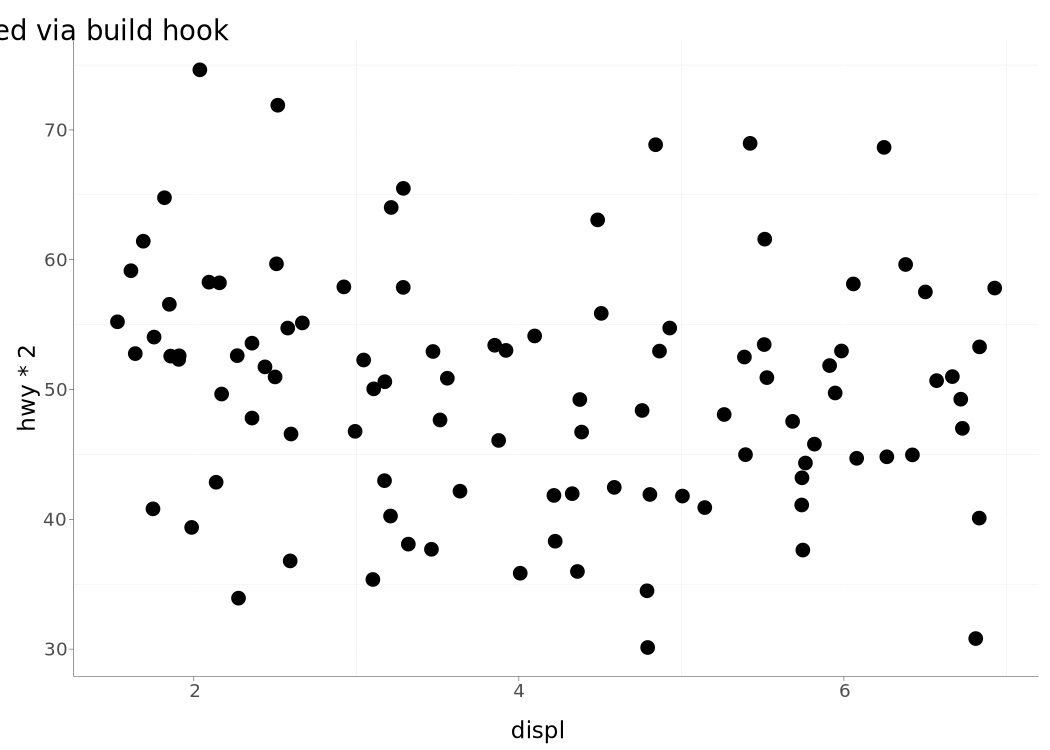

In [5]:
def scale_y(data, **ctx):
    """Double y values in every layer's DataFrame."""
    return [
        d.assign(y=d['y'] * 2) if 'y' in d.columns else d
        for d in data
    ]

p = (
    ggplot(mpg, aes(x='displ', y='hwy'))
    + geom_point()
    + labs(title='y values doubled via build hook', y='hwy * 2')
    + theme_minimal()
)

p.add_build_hook("after", BuildStage.COMPUTE_AESTHETICS, scale_y)
p

## 4. Diagnostic hook --- print data shape at each stage

For debugging complex plots, register hooks on multiple stages to see how
the data transforms through the pipeline.

In [6]:
diagnostics = []

def make_shape_hook(stage_name):
    """Factory: creates a hook that records per-layer shapes."""
    def hook(data, **ctx):
        shapes = [d.shape if hasattr(d, 'shape') else '(non-df)' for d in data]
        diagnostics.append((stage_name, shapes))
        return None  # return None = don't modify data
    return hook


p = (
    ggplot(mpg, aes(x='displ', y='hwy'))
    + geom_point()
    + theme_minimal()
)

# Attach diagnostic hooks to key stages
for stage_name in [
    BuildStage.LAYER_DATA,
    BuildStage.COMPUTE_AESTHETICS,
    BuildStage.COMPUTE_STAT,
    BuildStage.COMPUTE_POSITION,
    BuildStage.FINISH_DATA,
]:
    p.add_build_hook("after", stage_name, make_shape_hook(stage_name))

built = ggplot_build(p)

print("Data shape evolution through pipeline:")
print(f"  {'Stage':<25} {'Layer 0 shape'}")
print(f"  {'-'*25} {'-'*15}")
for stage_name, shapes in diagnostics:
    print(f"  {stage_name:<25} {shapes[0]}")

Data shape evolution through pipeline:
  Stage                     Layer 0 shape
  ------------------------- ---------------
  layer_data                (100, 4)
  compute_aesthetics        (100, 4)
  compute_stat              (100, 4)
  compute_position          (100, 4)
  finish_data               (100, 10)


## 5. Best practices

**When to use hooks:**
- Debugging / logging pipeline behavior
- Quick data transformations that don't warrant a custom Stat
- Research prototyping (test an idea before writing a proper extension)
- Injecting side effects (saving intermediate data to disk)

**When to use custom Stats/Geoms instead:**
- The transformation is reusable across many plots
- You need access to group-by semantics or positional adjustments
- The logic belongs in the public API of an extension package

**Rule of thumb:** hooks are for *introspection and ad-hoc modification*;
Stats/Geoms are for *reusable statistical transformations*.

## 6. Hook execution model

Key details:

| Aspect | Behavior |
|---|---|
| **Timing** | `"before"` runs before the stage; `"after"` runs after |
| **Signature** | `fn(data: List[DataFrame], **ctx) -> List[DataFrame] or None` |
| **Return value** | Return a new list to replace data; return `None` to leave unchanged |
| **Multiple hooks** | Multiple hooks on the same (timing, stage) run in registration order |
| **Context** | `**ctx` may include `layout`, `scales`, etc. depending on stage |
| **Chaining** | `add_build_hook` returns `self`, so you can chain: `p.add_build_hook(...).add_build_hook(...)` |
| **Scope** | Hooks are per-plot-instance; cloning via `_clone()` shares the hook list |

In [7]:
# Demonstrate chaining and None-return semantics
counts = {'before': 0, 'after': 0}

p = (
    ggplot(mpg, aes(x='hwy'))
    + geom_histogram(bins=10)
    + theme_minimal()
)

# Chain multiple hooks; return None = no modification
(
    p.add_build_hook("before", BuildStage.COMPUTE_STAT,
                     lambda data, **ctx: (counts.update(before=counts['before']+1), None)[-1])
     .add_build_hook("after", BuildStage.COMPUTE_STAT,
                     lambda data, **ctx: (counts.update(after=counts['after']+1), None)[-1])
)

built = ggplot_build(p)
print(f"Hook fire counts: {counts}")

Hook fire counts: {'before': 1, 'after': 1}
